# Import Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import joblib

# Load Dataset & Basic info

In [11]:
df = pd.read_csv("embedded_system_network_security_dataset.csv")

df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False


In [46]:
print("Shape :", df.shape)

Shape : (1000, 20)


In [47]:
print("\nColumns\n")
print(df.columns)


Columns

Index(['packet_size', 'inter_arrival_time', 'src_port', 'dst_port',
       'packet_count_5s', 'mean_packet_size', 'spectral_entropy',
       'frequency_band_energy', 'label', 'protocol_type_TCP',
       'protocol_type_UDP', 'src_ip_192.168.1.2', 'src_ip_192.168.1.3',
       'dst_ip_192.168.1.5', 'dst_ip_192.168.1.6', 'tcp_flags_FIN',
       'tcp_flags_SYN', 'tcp_flags_SYN-ACK', 'Prediction', 'Anomaly Score'],
      dtype='object')


In [48]:
print("\nInformation\n")
print(df.info())


Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   packet_size            1000 non-null   float64
 1   inter_arrival_time     1000 non-null   float64
 2   src_port               1000 non-null   int64  
 3   dst_port               1000 non-null   int64  
 4   packet_count_5s        1000 non-null   float64
 5   mean_packet_size       1000 non-null   float64
 6   spectral_entropy       1000 non-null   float64
 7   frequency_band_energy  1000 non-null   float64
 8   label                  1000 non-null   float64
 9   protocol_type_TCP      1000 non-null   bool   
 10  protocol_type_UDP      1000 non-null   bool   
 11  src_ip_192.168.1.2     1000 non-null   bool   
 12  src_ip_192.168.1.3     1000 non-null   bool   
 13  dst_ip_192.168.1.5     1000 non-null   bool   
 14  dst_ip_192.168.1.6     1000 non-null   bool

In [49]:
print("\nMissing Values\n")
print(df.isnull().sum())


Missing Values

packet_size              0
inter_arrival_time       0
src_port                 0
dst_port                 0
packet_count_5s          0
mean_packet_size         0
spectral_entropy         0
frequency_band_energy    0
label                    0
protocol_type_TCP        0
protocol_type_UDP        0
src_ip_192.168.1.2       0
src_ip_192.168.1.3       0
dst_ip_192.168.1.5       0
dst_ip_192.168.1.6       0
tcp_flags_FIN            0
tcp_flags_SYN            0
tcp_flags_SYN-ACK        0
Prediction               0
Anomaly Score            0
dtype: int64


In [50]:
print("\nClass Distribution\n")
print(df["label"].value_counts())


Class Distribution

label
0.0    900
1.0    100
Name: count, dtype: int64


In [22]:
X = df.drop("label", axis=1)

y = df["label"]

In [23]:
X = X.astype(int)

In [52]:
X.head(2)

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0,0,62569,443,0,0,0,0,0,1,1,0,0,0,0,0,0
1,0,0,59382,443,0,0,0,0,0,1,0,0,0,1,0,1,0


In [53]:
y.head(2)

0    0.0
1    0.0
Name: label, dtype: float64

# Feature Scaling

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [25]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.10,
    random_state=42
)

model.fit(X_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


# Predict

In [26]:
pred = model.predict(X_scaled)

pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# Performance

In [54]:
accuracy = accuracy_score(y, pred)

print("Accuracy :", accuracy)

Accuracy : 0.82


In [55]:
precision = precision_score(y, pred)

print("Precision :", precision)

Precision : 0.1


In [56]:
recall = recall_score(y, pred)

print("Recall :", recall)

Recall : 0.1


In [57]:
f1 = f1_score(y, pred)

print("F1 Score :", f1)

F1 Score : 0.1


In [58]:
cm = confusion_matrix(y, pred)

print(cm)

[[810  90]
 [ 90  10]]


In [34]:
df["Prediction"] = pred

df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK,Prediction
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False,0
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False,0
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False,0
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False,0
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False,0


In [35]:
print(classification_report(y, pred))

              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90       900
         1.0       0.10      0.10      0.10       100

    accuracy                           0.82      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.82      0.82      0.82      1000



# Find Anomalies

In [36]:
anomalies = df[df["Prediction"] == 1]

print("Total Anomalies :", len(anomalies))

anomalies.head()

Total Anomalies : 100


,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK,Prediction
11,0.053686,0.699422,59244,443,0.500000,0.0,0.018393,0.321347,0.0,False,True,False,True,False,True,True,False,False,1
16,0.935576,0.312725,4734,80,1.000000,0.0,0.803745,0.364619,0.0,False,False,True,False,False,False,False,False,False,1
21,0.312097,0.135935,17182,80,1.000000,0.0,0.400535,0.879835,0.0,True,False,True,False,False,True,False,True,False,1
31,0.161059,0.298670,5866,80,0.071429,0.0,0.282743,0.540690,0.0,True,False,True,False,False,True,False,True,False,1
41,0.256979,0.776957,56362,80,1.000000,0.0,0.534514,0.735092,0.0,True,False,False,True,False,True,True,False,False,1


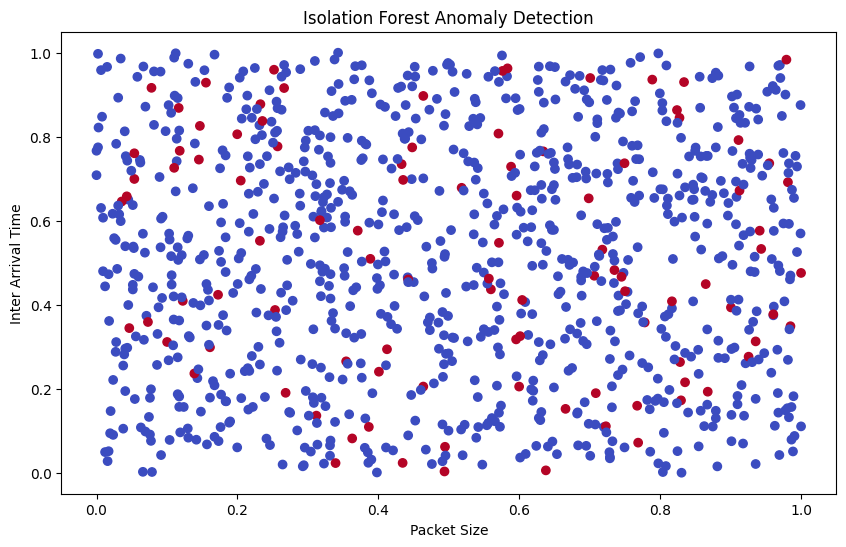

In [37]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["packet_size"],
    df["inter_arrival_time"],
    c=df["Prediction"],
    cmap="coolwarm"
)

plt.xlabel("Packet Size")
plt.ylabel("Inter Arrival Time")
plt.title("Isolation Forest Anomaly Detection")

plt.show()

# Save Model

In [38]:
joblib.dump(model,"IsolationForest.pkl")

['IsolationForest.pkl']

In [39]:
joblib.dump(scaler,"Scaler.pkl")

['Scaler.pkl']

In [61]:
loaded_model = joblib.load("IsolationForest.pkl")

loaded_scaler = joblib.load("Scaler.pkl")

# Predict One New Sample

In [63]:
sample = X.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)

prediction = np.where(prediction==1,0,1)

print(prediction)

[0]


In [64]:
scores = model.decision_function(X_scaled)

df["Anomaly Score"] = scores

df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK,Prediction,Anomaly Score
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False,0,0.022863
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False,0,0.006520
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False,0,0.058589
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False,0,0.103833
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False,0,0.044505


In [65]:
df.sort_values(
    by="Anomaly Score"
).head(20)

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK,Prediction,Anomaly Score
670,0.745168,0.466456,61683,80,1.0,0.0,0.554119,0.393273,0.0,True,False,False,True,True,False,False,True,False,1,-0.084544
737,0.155333,0.928721,38410,443,1.0,0.0,0.958002,0.369060,0.0,True,False,False,True,True,False,False,True,False,1,-0.081023
127,0.717967,0.531202,2683,443,1.0,0.0,0.159007,0.265219,0.0,False,False,True,False,True,False,False,True,False,1,-0.077595
560,0.637795,0.005610,14218,443,1.0,0.0,0.769447,0.281429,0.0,False,True,True,False,False,True,True,False,False,1,-0.073811
137,0.388690,0.509244,53735,443,1.0,0.0,0.137579,0.011378,0.0,False,True,True,False,True,False,False,False,True,1,-0.073257
781,0.788833,0.936000,5566,53,1.0,0.0,0.566262,0.973056,0.0,True,False,True,False,True,False,True,False,False,1,-0.073248
933,0.172513,0.423670,64871,443,1.0,0.0,0.012472,0.986927,0.0,False,True,True,False,False,False,True,False,False,1,-0.070455
696,0.722978,0.110637,4014,80,1.0,0.0,0.968903,0.443069,1.0,False,True,False,False,False,True,False,True,False,1,-0.070273
810,0.833930,0.930115,46914,443,1.0,0.0,0.230491,0.073287,0.0,True,False,False,True,False,True,True,False,False,1,-0.069019
245,0.251969,0.959502,26964,80,1.0,0.0,0.170591,0.277243,0.0,True,False,True,False,True,False,False,False,True,1,-0.060592


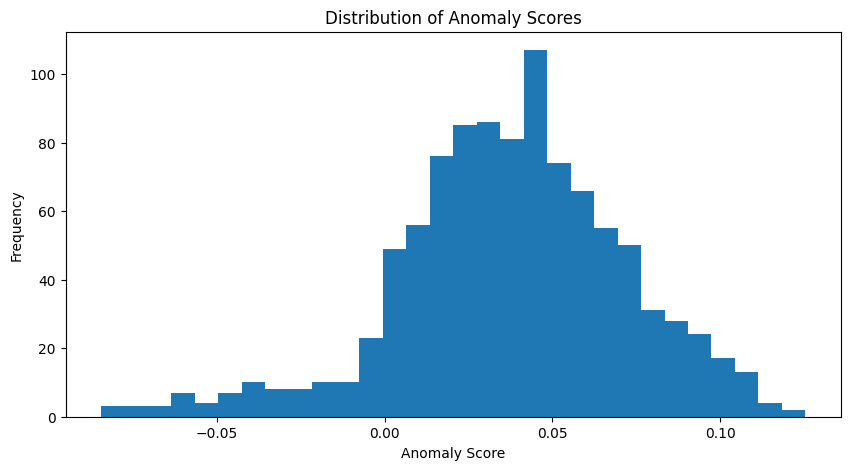

In [66]:
plt.figure(figsize=(10,5))

plt.hist(df["Anomaly Score"], bins=30)

plt.xlabel("Anomaly Score")

plt.ylabel("Frequency")

plt.title("Distribution of Anomaly Scores")

plt.show()